In [51]:
with h5py.File('outputs/dm_proto_mstar_weighted.hdf5', 'r') as g:
    print(g['halo_10293151'].keys())

<KeysViewHDF5 ['GroupBHMass', 'GroupBHMdot', 'GroupCM', 'GroupContaminationFracByMass', 'GroupContaminationFracByNumPart', 'GroupFirstSub', 'GroupGasMetalFractions', 'GroupGasMetallicity', 'GroupLen', 'GroupLenType', 'GroupMass', 'GroupMassType', 'GroupNsubs', 'GroupOffsetType', 'GroupOrigHaloID', 'GroupPos', 'GroupPrimaryZoomTarget', 'GroupSFR', 'GroupStarMetalFractions', 'GroupStarMetallicity', 'GroupVel', 'GroupWindMass', 'Group_Fe_Crit200', 'Group_Fe_Crit500', 'Group_Fgas_Crit200', 'Group_Fgas_Crit500', 'Group_Fgas_Crit500_max', 'Group_M_Crit200', 'Group_M_Crit500', 'Group_M_Mean200', 'Group_M_TopHat200', 'Group_R_Crit200', 'Group_R_Crit500', 'Group_R_Mean200', 'Group_R_TopHat200', 'InfoID', 'InfoType', 'SimulationName', 'SnapshotNumber', 'TracerLengthType', 'TracerOffsetType', 'subhalos', 'trace']>


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
weight = 'sfr'
with h5py.File(f'outputs/dm_proto_{weight}_weighted.hdf5', 'r') as g:
    print(g.keys())
    ex = g['halo_5348822']
    keys = ex.keys()
    print(keys)
    with h5py.File('outputs/tng_cluster_catalog.hdf5', 'a') as f:
        halo_ids = f['table']['haloID'][:]
        if 'table' not in f:
            f.create_group('table')
        for k in f.keys():
            if k not in ('trace_mstar', 'trace_sfr', 'subhalos', 'table'):
                print(k)
                if 'table/' + k in f:
                    del f['table/' + k]
                f.copy(k, 'table/' + k)
                # f['table/' + k] = f[k]
                del f[k]
        for key in keys:
            newkey = 'table/' + key
            if key == 'subhalos':
                newkey = 'subhalos'
            if key == 'trace':
                newkey = 'trace_' + weight
            if key in f:
                del f[key]
            if newkey in f:
                del f[newkey]
            if key in ('subhalos', 'trace'):
                f.create_group(newkey)
                for (i, halo_id) in enumerate(halo_ids):
                    path = 'halo_' + str(halo_id) + '/' + key
                    if path in g:
                        f.create_group(newkey + '/halo_' + str(halo_id))
                        # print(path, newkey  + '/halo_' + str(halo_id))
                        # g.copy(path, f[newkey + '/halo_' + str(halo_id)])
                        for name, item in g[path].items():
                            g.copy(item, f[newkey + '/halo_' + str(halo_id)], name=name)
            else:
                f.create_dataset(newkey, shape=(*halo_ids.shape, *ex[key].shape), dtype=ex[key].dtype)
                for (i, halo_id) in enumerate(halo_ids):
                    path = 'halo_' + str(halo_id) + '/' + key
                    if path in g:
                        f[newkey][i] = g[path]



<KeysViewHDF5 ['halo_0', 'halo_10293151', 'halo_10351684', 'halo_10422957', 'halo_10672584', 'halo_1068507', 'halo_10943032', 'halo_11069985', 'halo_11375033', 'halo_11823213', 'halo_11988378', 'halo_12045848', 'halo_12109950', 'halo_1263653', 'halo_1263657', 'halo_1263675', 'halo_12925051', 'halo_13388143', 'halo_13737851', 'halo_1431487', 'halo_14346920', 'halo_15304908', 'halo_15386300', 'halo_15543148', 'halo_1580995', 'halo_1580997', 'halo_15989517', 'halo_17283896', 'halo_17315356', 'halo_17469184', 'halo_1763505', 'halo_17902778', 'halo_18083789', 'halo_18373384', 'halo_18421127', 'halo_18602076', 'halo_18788091', 'halo_18909008', 'halo_19184395', 'halo_1921024', 'halo_2069291', 'halo_2213486', 'halo_2380799', 'halo_252455', 'halo_252459', 'halo_2637623', 'halo_2771226', 'halo_2892630', 'halo_2892634', 'halo_3020669', 'halo_3135769', 'halo_3238091', 'halo_3343359', 'halo_3457081', 'halo_3556542', 'halo_3656685', 'halo_3656694', 'halo_3758345', 'halo_3863281', 'halo_3863298', 'ha

In [17]:
with h5py.File('outputs/tng_cluster_catalog.hdf5', 'r') as f:
    print(f['trace_mstar'])
    print(f['trace_sfr'])

<HDF5 group "/trace_mstar" (41 members)>
<HDF5 group "/trace_sfr" (30 members)>


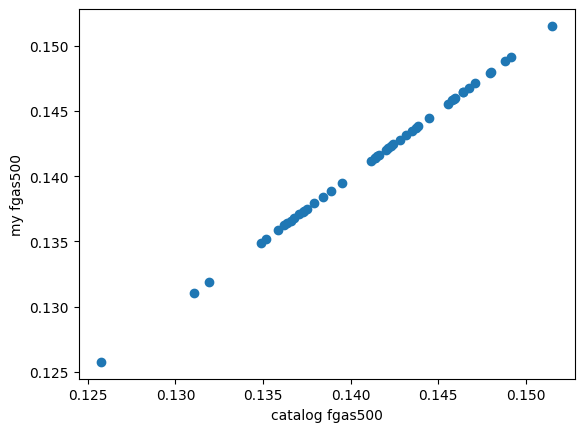

In [111]:
with h5py.File('outputs/tng_cluster_catalog.hdf5', 'r') as f:
    x = f['table/fgas_r500'][:]
    y = f['table/Group_Fgas_Crit500'][:]
    plt.scatter(x[y>0], y[y>0])
    plt.xlabel('catalog fgas500')
    plt.ylabel('my fgas500')